In [33]:
import matplotlib.pyplot as plt
%matplotlib widget

from mastu import HSV
import numpy as np
import BESplotting as bp

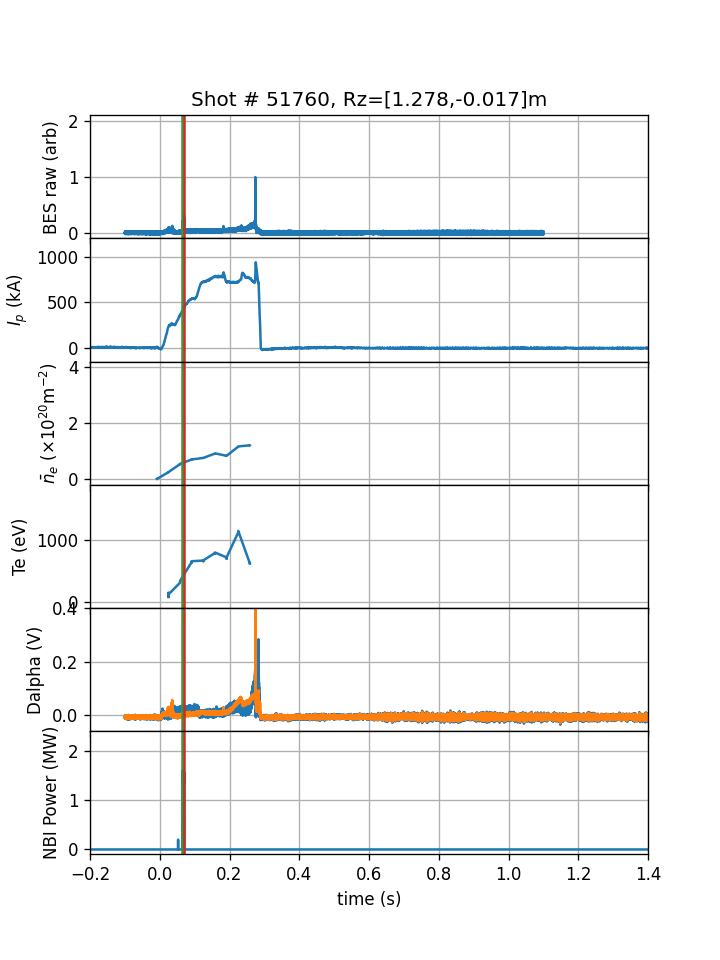

In [34]:
shotn = 51760
bp.subplotsBES(shotn)

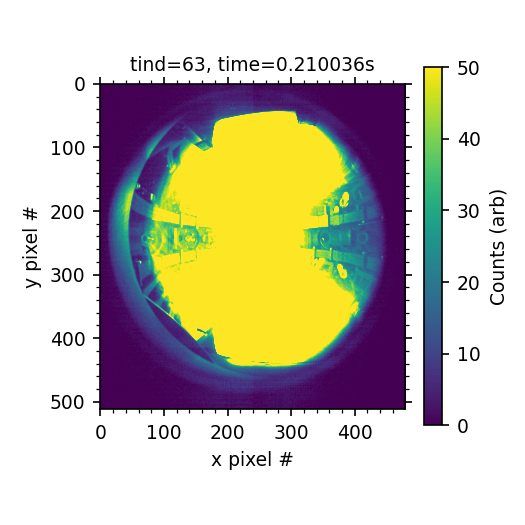

In [41]:
tind = 63



data, time = HSV.getSingle(shotn, tind)
fig, ax = plt.subplots(1, 1, figsize=(3.5,3.5), dpi=150)
im=ax.imshow(data, vmin=0, vmax=50)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Counts (arb)', fontsize=9)
cbar.ax.tick_params(labelsize=9)

ax.set_title(f'tind={tind}, time={time:.6f}s', fontsize=9)
ax.set_xlabel('x pixel #', fontsize=9)
ax.set_ylabel('y pixel #', fontsize=9)

ax.tick_params(
    axis="both", which='both', labelsize=9, direction='out', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()

plt.tight_layout()

In [42]:
HSV.makeImage(shotn, tind, )

Text(0.5, 1.0, '0.600016')

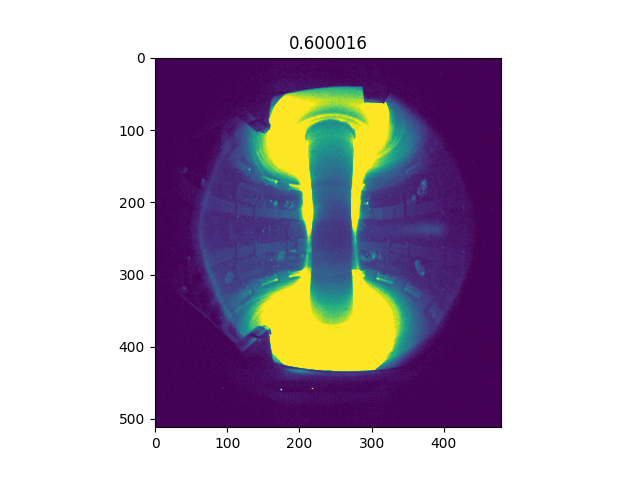

In [4]:
data, time = HSV.getSingle(50498, 600)
plt.figure()
plt.imshow(data, vmin=0, vmax=50)
plt.title(time)

In [13]:
file = np.load('/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz')

['Rmin0', 'zmin0', 'phi0', 'Rmin', 'zmin', 'phi']

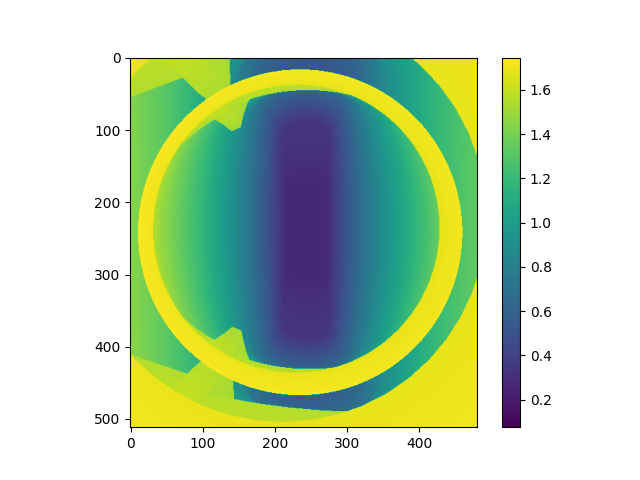

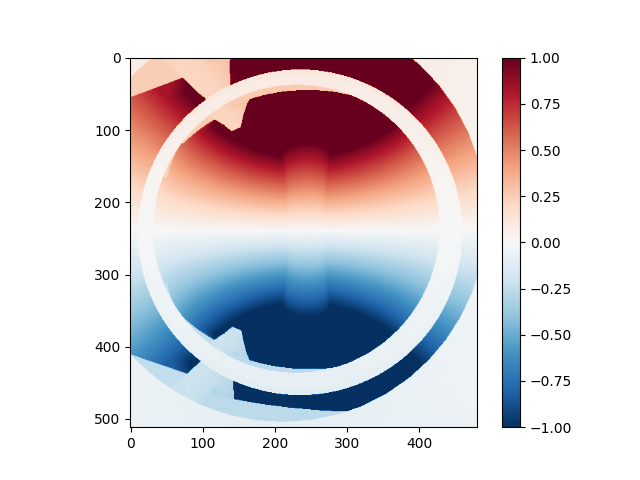

In [21]:
plt.figure()
plt.imshow(file['Rmin'])
plt.colorbar()

plt.figure()
plt.imshow(file['zmin'], vmin=-1., vmax=1., cmap=plt.cm.RdBu_r)
plt.colorbar()

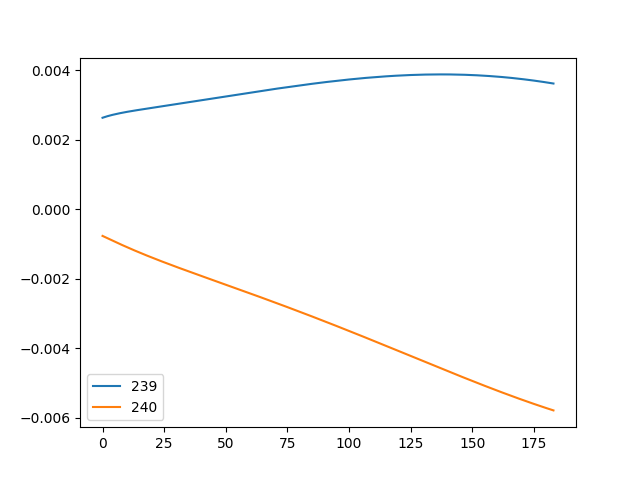

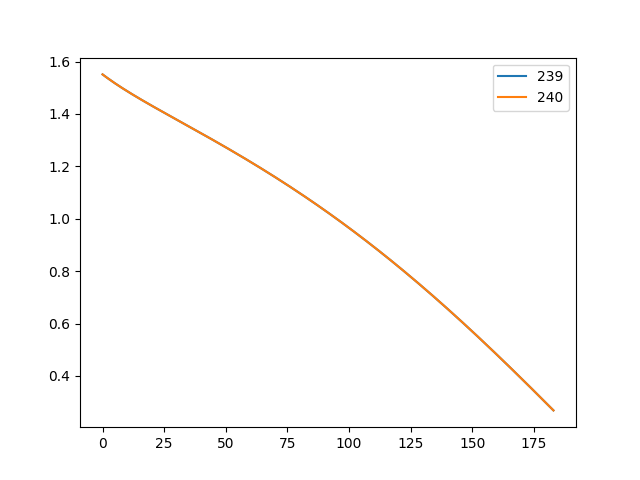

In [30]:
I = 239
J = 241
II = 32
JJ = 216
plt.figure()
for i in range(I, J):
    plt.plot(file['zmin'][i,II:JJ], label=i)
plt.legend()

plt.figure()
for i in range(I, J):
    plt.plot(file['Rmin'][i,II:JJ], label=i)
plt.legend()

In [31]:
np.std(file['zmin'][239,II:JJ])

0.00037135365625871734

In [32]:
np.std(file['zmin'][240,II:JJ])

0.0014552789781445909

In [51]:
frames, time = HSV.get(50498)

In [53]:
R0, z0 = HSV.getRz(
    '/home/sthoma/tokamak_inversion_routines/mastu/Coordinates/50499_1037.npz', 
    239, 240, 32, 216)

In [54]:
import functions as fn

In [57]:
R, goodChans, flipBool = fn.prepR(R0, 1.8)

In [58]:
dSlice = (slice(239,240), slice(32,216), slice(0,len(time)))

In [60]:
frames.shape # (512,480,1125)
data = frames[dSlice][0]
data = data[goodChans,:].T
print(data.shape)

(1125, 184)


In [61]:
data[1124:].shape

(1, 184)

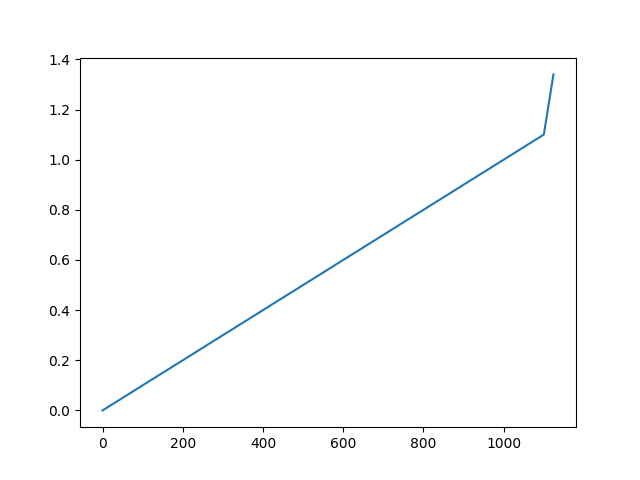

In [43]:
plt.figure()
plt.plot(frames.frame_times)